# Etapa 1 · Análisis exploratorio, preprocesamiento y fuga de datos

**Proyecto Integrador de Aprendizaje Automático** · Donnys Torres Lozano · Maestría en Analítica de Datos, Universidad del Norte

Este cuaderno cumple tres propósitos. Primero se explora y se depura el archivo `heart.csv`. Luego se demuestra qué es la fuga de datos (*data leakage*) y cuánto distorsiona las métricas. Al final se comparan siete clasificadores con `Pipeline` y `GridSearchCV` y se presenta el ranking.

Antes de empezar hay dos ajustes frente al código de ejemplo del enunciado, y ambos son necesarios para que funcione con este archivo. La variable objetivo se llama `HeartDisease` y no `target`. Y el archivo tiene cinco columnas de texto, de modo que no se puede aplicar `MinMaxScaler` directamente sobre `X`: primero hay que codificarlas, y eso se hace dentro del `Pipeline` con un `ColumnTransformer`.

In [1]:
import sys, warnings
sys.path.insert(0, "..")          # para importar el paquete src/ del proyecto
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import heart_ml as h

pd.set_option("display.max_colwidth", 90)
AZUL, NARANJA, GRIS = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

## 1. Exploración y depuración

In [2]:
crudo = pd.read_csv(h.RUTA_DATOS)
print("Filas y columnas:", crudo.shape)
print("Nulos:", int(crudo.isna().sum().sum()), "| Filas repetidas:", int(crudo.duplicated().sum()))
print("Ceros en RestingBP:", int((crudo.RestingBP == 0).sum()), "| Ceros en Cholesterol:", int((crudo.Cholesterol == 0).sum()))
crudo.head()

Filas y columnas: (918, 12)
Nulos: 0 | Filas repetidas: 0
Ceros en RestingBP: 1 | Ceros en Cholesterol: 172


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
crudo.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.51,9.43,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.40,18.51,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.80,109.38,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.23,0.42,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.81,25.46,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.89,1.07,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.55,0.50,0.0,0.00,1.0,1.0,1.0


In [4]:
sin_col = (crudo.Cholesterol == 0).map({True: "Colesterol = 0", False: "Colesterol medido"})
t = pd.crosstab(sin_col, crudo.HeartDisease.map({0: "Sin enfermedad", 1: "Con enfermedad"}))
t["% con enfermedad"] = (100 * t["Con enfermedad"] / t.sum(axis=1)).round(1)
t

HeartDisease,Con enfermedad,Sin enfermedad,% con enfermedad
Cholesterol,,,
Colesterol = 0,152,20,88.4
Colesterol medido,356,390,47.7


**Lectura.** El archivo tiene 918 pacientes y 12 columnas, sin nulos y sin filas repetidas. Sin embargo, 172 registros traen el colesterol en cero y 1 trae la presión arterial en cero, valores que no son posibles en un paciente vivo. De los 172 pacientes sin colesterol, el 88,4 % tiene enfermedad, frente al 47,7 % de los demás.

**Implicación predictiva.** Los ceros son datos faltantes ocultos y no faltan al azar. Si se dejan como mediciones, el modelo aprende que «colesterol bajo implica enfermedad», lo cual es falso.

**Acción recomendada.** Eliminar el único registro con presión en cero y tratar el colesterol en cero como faltante, imputándolo con la mediana dentro del `Pipeline`. De esta forma la mediana se calcula solo con entrenamiento.

In [5]:
df = h.cargar_datos()
print("Registros para el modelado:", len(df))
print(df.HeartDisease.value_counts().rename({1: "Con enfermedad", 0: "Sin enfermedad"}).to_string())

Registros para el modelado: 917
HeartDisease
Con enfermedad    507
Sin enfermedad    410


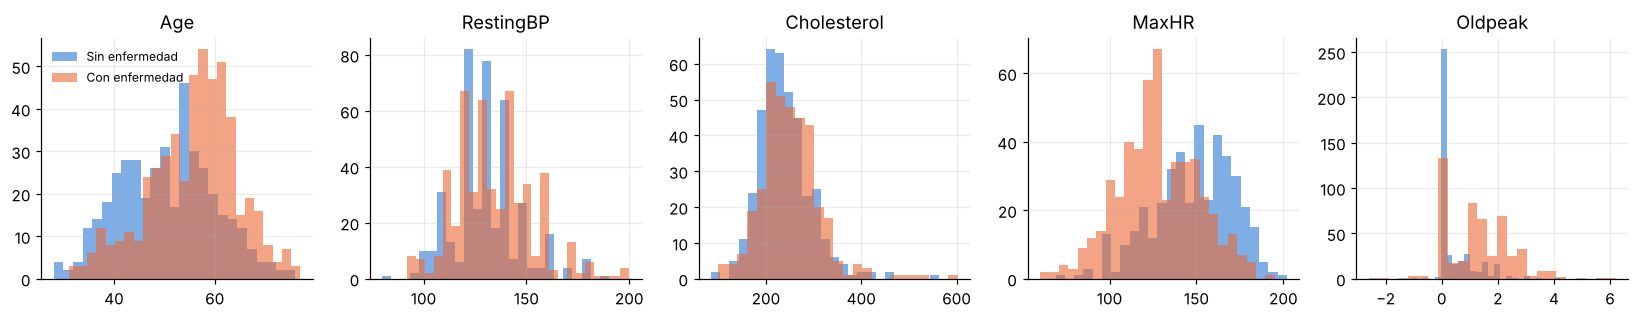

In [6]:
fig, ejes = plt.subplots(1, 5, figsize=(15, 3))
for eje, var in zip(ejes, ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]):
    datos = df[df[var] > 0] if var == "Cholesterol" else df
    for clase, color, nombre in ((0, AZUL, "Sin enfermedad"), (1, NARANJA, "Con enfermedad")):
        eje.hist(datos.loc[datos.HeartDisease == clase, var], bins=25, alpha=0.6, color=color, label=nombre)
    eje.set_title(var)
ejes[0].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

**Lectura.** `MaxHR` y `Oldpeak` son las variables numéricas donde más se separan los dos grupos; en `RestingBP` y `Cholesterol` las distribuciones casi coinciden.

**Implicación predictiva.** Ninguna variable separa las clases por sí sola. El modelo debe combinar varias señales.

**Acción recomendada.** Conservar todas las variables y dejar que la comparación de modelos determine cuánto aporta cada una.

## 2. Demostración de la fuga de datos

La fuga de datos ocurre cuando el modelo recibe, durante el entrenamiento, información que no tendría al momento de predecir. El resultado es una métrica inflada que no se sostiene en producción. Se muestran tres casos.

### Caso A. Fuga del objetivo

Se agrega la variable artificial del enunciado, `leaky_feature`, que es la respuesta más un ruido mínimo.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

X, y = df[h.COLUMNAS], df[h.OBJETIVO]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=h.SEMILLA)
rejilla = {"clf__C": [0.1, 1, 10], "clf__gamma": [0.01, 0.1]}

np.random.seed(0)
X_fuga = X.copy()
X_fuga["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))

Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_fuga, y, test_size=0.2, stratify=y, random_state=h.SEMILLA)
prep_a = h.construir_preprocesador()
prep_a.transformers.append(("fuga", MinMaxScaler(), ["leaky_feature"]))
grid_a = GridSearchCV(Pipeline([("prep", prep_a), ("clf", SVC(probability=True, random_state=h.SEMILLA))]),
                      rejilla, cv=cv, scoring="roc_auc").fit(Xa_train, ya_train)
auc_a = roc_auc_score(ya_test, grid_a.predict_proba(Xa_test)[:, 1])
print(f"AUC con fuga del objetivo: {auc_a:.3f}")

AUC con fuga del objetivo: 1.000


**Lectura.** El AUC es de 1,000: el modelo clasifica perfectamente.

**Implicación predictiva.** Un resultado perfecto en datos clínicos reales es una señal de alarma y no un logro. El modelo no aprendió nada sobre el paciente; solo leyó la respuesta. Hay que advertir que en el código de ejemplo del enunciado el flujo «sin fuga» también conserva `leaky_feature` en `X`, de modo que los dos AUC salen cercanos a 1 y la comparación no muestra diferencia. Aquí se separan los dos tipos de fuga para que el efecto de cada uno se vea.

**Acción recomendada.** Revisar toda variable que tenga una correlación casi perfecta con el objetivo, y preguntar siempre si ese dato existiría antes del diagnóstico.

### Caso B. Fuga en el preprocesamiento

Aquí no hay variable tramposa. El error es ajustar el preprocesamiento (imputación, escalado y codificación) con todos los datos antes de dividirlos.

In [8]:
# CON fuga: el preprocesador ve todos los datos, incluido el futuro conjunto de prueba
X_todo = h.construir_preprocesador().fit_transform(X)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_todo, y, test_size=0.2, stratify=y, random_state=h.SEMILLA)
grid_b = GridSearchCV(SVC(probability=True, random_state=h.SEMILLA), {"C": [0.1, 1, 10], "gamma": [0.01, 0.1]},
                      cv=cv, scoring="roc_auc").fit(Xb_train, yb_train)
auc_b = roc_auc_score(yb_test, grid_b.predict_proba(Xb_test)[:, 1])

# SIN fuga: se divide primero y el preprocesador va dentro del Pipeline
X_train, X_test, y_train, y_test = h.dividir(df)
grid_c = h.train_pipeline(X_train, y_train, SVC(probability=True, random_state=h.SEMILLA), rejilla)
auc_c = roc_auc_score(y_test, grid_c.predict_proba(X_test)[:, 1])

pd.DataFrame({"Flujo": ["Con fuga de preprocesamiento", "Sin fuga (Pipeline)"],
              "AUC validación cruzada": [grid_b.best_score_, grid_c.best_score_],
              "AUC prueba": [auc_b, auc_c]}).round(3)

,Flujo,AUC validación cruzada,AUC prueba
0,Con fuga de preprocesamiento,0.917,0.926
1,Sin fuga (Pipeline),0.917,0.931


**Lectura.** Con fuga de preprocesamiento el AUC de prueba es de 0,926 y sin fuga es de 0,931. En validación cruzada ambos dan 0,917.

**Implicación predictiva.** En este dataset la fuga de preprocesamiento casi no cambia el resultado, y es importante decirlo con honestidad. La razón es que el mínimo, el máximo y la mediana de 917 pacientes son prácticamente iguales con o sin los 184 de prueba; por ejemplo, la mediana del colesterol es de 237 con todos los datos y de 239 solo con entrenamiento. Esto no significa que la práctica sea inofensiva: su efecto depende de cuánta información del objetivo use el paso de preprocesamiento, como muestra el caso siguiente.

**Acción recomendada.** Usar siempre el `Pipeline`, aunque aquí el efecto sea pequeño. No cuesta nada y protege cuando el preprocesamiento es más agresivo.

### Caso C. Cuándo la fuga de preprocesamiento sí es grave

Se generan 5.000 variables de ruido puro, sin ninguna relación con la enfermedad, y se seleccionan las 20 más asociadas al objetivo.

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

ruido = np.random.default_rng(0).normal(size=(len(y), 5000))

# CON fuga: la selección usa todas las filas antes de validar
ruido_sel = SelectKBest(f_classif, k=20).fit_transform(ruido, y)
con_fuga = cross_val_score(LogisticRegression(max_iter=1000), ruido_sel, y, cv=cv, scoring="roc_auc")

# SIN fuga: la selección va dentro del Pipeline y se repite en cada pliegue
pipe = Pipeline([("sel", SelectKBest(f_classif, k=20)), ("clf", LogisticRegression(max_iter=1000))])
sin_fuga = cross_val_score(pipe, ruido, y, cv=cv, scoring="roc_auc")

print(f"AUC con fuga: {con_fuga.mean():.3f} ± {con_fuga.std():.3f}")
print(f"AUC sin fuga: {sin_fuga.mean():.3f} ± {sin_fuga.std():.3f}")

AUC con fuga: 0.731 ± 0.034
AUC sin fuga: 0.488 ± 0.021


**Lectura.** Con variables que son ruido puro, el flujo con fuga reporta un AUC de 0,731 ± 0,034. El flujo correcto reporta 0,488 ± 0,021, que es el azar.

**Implicación predictiva.** La fuga fabricó 0,24 puntos de AUC a partir de nada. Un modelo así se presentaría como útil y fallaría por completo con pacientes nuevos. La diferencia con el caso B es que la selección de variables usa la respuesta, y el escalado no.

**Acción recomendada.** Todo paso que aprenda algo de los datos, sea escalado, imputación, codificación o selección de variables, va dentro del `Pipeline`.

## 3. Comparación de modelos con Pipeline y GridSearchCV

La lógica de entrenamiento está encapsulada en funciones reutilizables del módulo `src/heart_ml.py`: `construir_preprocesador`, `train_pipeline`, `evaluar` y `comparar_modelos`. Cada modelo va dentro de un `Pipeline` y se optimiza con `GridSearchCV` de 5 pliegues estratificados, usando el AUC como criterio.

In [10]:
import inspect
print(inspect.getsource(h.train_pipeline))

def train_pipeline(X_train, y_train, model, param_grid, cv=5):
    """Entrena un Pipeline (preprocesamiento + modelo) con GridSearchCV y AUC como criterio."""
    pipe = Pipeline([("prep", construir_preprocesador()), ("clf", model)])
    pliegues = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEMILLA)
    grid = GridSearchCV(pipe, param_grid, cv=pliegues, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid



In [11]:
ranking, ajustados = h.comparar_modelos(X_train, y_train, X_test, y_test)
ranking.round(3)

,Modelo,AUC CV (media),AUC CV (desv.),AUC prueba,Exactitud prueba,Precisión prueba,Sensibilidad prueba,Mejores hiperparámetros
Puesto,,,,,,,,
1,RandomForest,0.931,0.018,0.931,0.880,0.885,0.902,"{'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 400}"
2,GradientBoosting,0.929,0.009,0.924,0.886,0.893,0.902,"{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}"
3,LogisticRegression,0.918,0.024,0.935,0.880,0.877,0.912,{'C': 1}
4,SVC,0.917,0.037,0.931,0.853,0.864,0.873,"{'C': 1, 'gamma': 0.1}"
5,KNN,0.916,0.029,0.928,0.870,0.890,0.873,"{'n_neighbors': 31, 'weights': 'distance'}"
6,GaussianNB,0.908,0.015,0.909,0.875,0.891,0.882,{'var_smoothing': 1e-09}
7,DecisionTree,0.905,0.026,0.886,0.842,0.848,0.873,"{'max_depth': 8, 'min_samples_leaf': 20}"


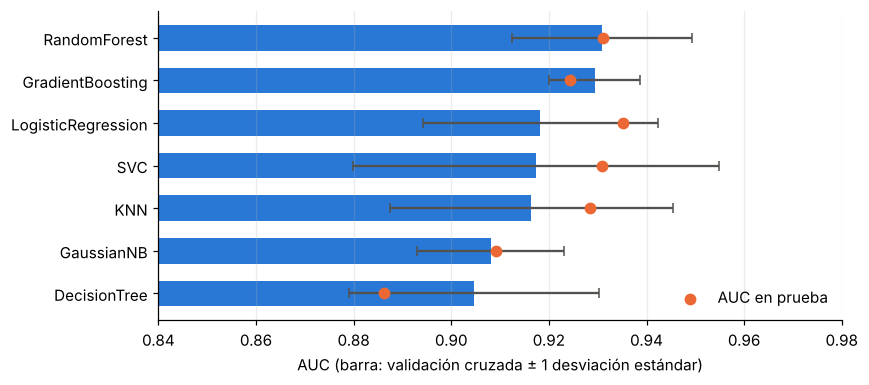

In [12]:
r = ranking.sort_values("AUC CV (media)")
fig, eje = plt.subplots(figsize=(8, 3.6))
eje.barh(r["Modelo"], r["AUC CV (media)"], xerr=r["AUC CV (desv.)"], color=AZUL, height=0.6,
         error_kw={"ecolor": GRIS, "capsize": 3})
eje.scatter(r["AUC prueba"], r["Modelo"], color=NARANJA, zorder=3, s=45, label="AUC en prueba")
eje.set_xlim(0.84, 0.98); eje.set_xlabel("AUC (barra: validación cruzada ± 1 desviación estándar)")
eje.legend(frameon=False, loc="lower right"); eje.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Lectura.** El ranking por AUC de validación cruzada queda así: RandomForest (0,931), GradientBoosting (0,929), LogisticRegression (0,918), SVC (0,917), KNN (0,916), GaussianNB (0,908) y DecisionTree (0,905). En prueba, la exactitud va de 0,842 a 0,886 y el AUC de 0,886 a 0,935.

**Implicación predictiva.** Los cinco primeros modelos están separados por 0,015 de AUC, y la desviación estándar entre pliegues va de 0,009 a 0,037. Las barras de error se traslapan, de modo que no hay un ganador estadísticamente claro. Además, el orden cambia según la métrica: en prueba la Regresión Logística tiene el mayor AUC (0,935) y GradientBoosting la mayor exactitud (0,886). Solo el árbol de decisión individual queda claramente por debajo.

**Acción recomendada.** Elegir el modelo por el AUC de validación cruzada y no por el de prueba, porque escoger con el conjunto de prueba sería otra forma de fuga. Con ese criterio se selecciona RandomForest para el despliegue. Igual queda documentado que la Regresión Logística es una alternativa defendible, más simple y más fácil de explicar, con un desempeño equivalente.